In [182]:
# Load Libreries..
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
data = pd.read_csv("car_price_prediction_.csv") # load Dataset

In [184]:
data.head()  # head() --> starting five value from dataset

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [185]:
data.isnull().sum()  # Missing Value 

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [186]:
data.info()  # About Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [187]:
data.describe()  

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [188]:
data = data.drop(columns = "Model",axis = True)  # drop --> Remove column

In [189]:
data.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10


In [190]:
data["Brand"].value_counts()  # All Value in Columns

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [191]:
data["CARnew_age"] = 2026 - data["Year"] # create new column

In [192]:
data.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,CARnew_age
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,10
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,8
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,13
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,15
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,17


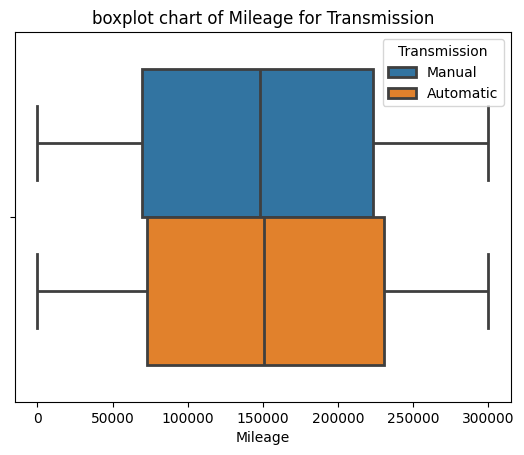

In [193]:
# look the BOX chart of Mileage by Transmission

sns.boxplot(x="Mileage",data = data,hue = "Transmission",linewidth=2)
plt.title("boxplot chart of Mileage by Transmission")
plt.show()

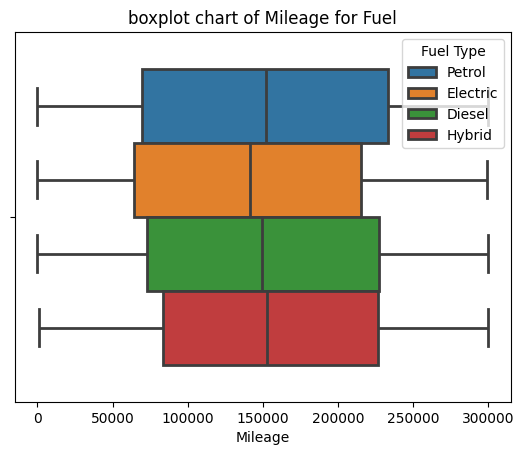

In [194]:
# look the BOX chart of Mileage by fuel

sns.boxplot(x="Mileage",data = data,hue = "Fuel Type",linewidth=2)
plt.title("boxplot chart of Mileage by Fuel")
plt.show()

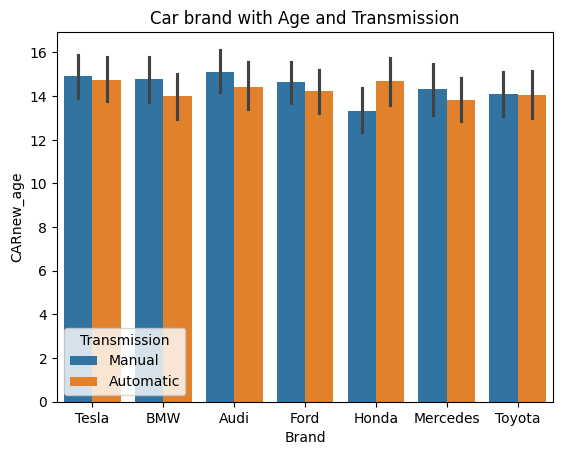

In [195]:
# look the BAR chart of Car brand with Age and Transmission

sns.barplot(x="Brand",y="CARnew_age",data= data,hue="Transmission")
plt.title("Car brand with Age and Transmission")
plt.show()

In [196]:
data["Transmission"].value_counts()  

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [197]:
from sklearn.preprocessing import LabelEncoder  
# Load LabelEncoder model --> convert Categorical data to Numerical data 

In [198]:
le = LabelEncoder()  # load DATA
transmission_no = pd.DataFrame(le.fit_transform(data["Transmission"]))

In [199]:
data = pd.get_dummies(
    data,
    columns=["Brand", "Fuel Type", "Transmission","Condition"],
    drop_first=True,dtype=int
)

In [200]:
data.head()

,Car ID,Year,Engine Size,Mileage,Price,CARnew_age,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Transmission_Manual,Condition_New,Condition_Used
0,1,2016,2.3,114832,26613.92,10,0,0,0,0,1,0,0,0,1,1,1,0
1,2,2018,4.4,143190,14679.61,8,1,0,0,0,0,0,1,0,0,1,0,1
2,3,2013,4.5,181601,44402.61,13,0,0,0,0,0,0,1,0,0,1,1,0
3,4,2011,4.1,68682,86374.33,15,0,0,0,0,1,0,0,0,0,0,1,0
4,5,2009,2.6,223009,73577.10,17,0,1,0,0,0,0,0,0,0,1,0,0


In [201]:
data.shape  # data size 

(2500, 18)

In [202]:
# Divided the data in X AND Y Form.

x = data.drop("Price", axis=1)
y = data[["Price"]]

In [203]:
# load model --> Train Test Split
from sklearn.model_selection import train_test_split 

In [204]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)  # train 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 17)
(500, 17)
(2000, 1)
(500, 1)


In [205]:
# load 1st Model --> LinearRegression
from sklearn.linear_model import LinearRegression   

In [206]:
lr = LinearRegression()  # train model
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [215]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,recall_score

In [216]:
r2_score(y_test,lr.predict(x_test))*100  # predict Accuracy score

-0.4403654184190531

In [223]:
import numpy as np
mae = mean_absolute_error(y_test,lr.predict(x_test))   
mse = np.sqrt(mean_squared_error(y_test,lr.predict(x_test)))

In [225]:
print(mae)    # mean_absolute_error

23755.852439563216


In [226]:
print(mse)    # mean_squared_error

27584.222577143188


In [227]:
# load 2nd model --> RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

In [228]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(x_train,y_train) # train model

C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [230]:
r2_score(y_test,rfr.predict(x_test))*100  # predict test Accuracy 

-4.240927383830528

In [231]:
import numpy as np
mae = mean_absolute_error(y_test,rfr.predict(x_test))
mse = np.sqrt(mean_squared_error(y_test,rfr.predict(x_test)))

In [232]:
print(mae)  # mean_absolute_error

24186.8384944


In [233]:
print(mse) # mean_squared_error

28101.256537739835


In [ ]:
#       model                  Accuracy                      MAE                    MSE
1.   LinearRegression  -    0.4403654184190531       23755.852439563216        27584.222577143188
2.  RandomForestRegressor -  4.240927383830528         24186.8384944           28101.256537739835  

Linear Regression And RandomForestRegressor performed best based on the test accuracy And metrics And mean_absolute_error, mean_squared_error.
Therefore, it was selected as the best-performing model.